# Lab Task 04 - Part 1

# The following code comes from the lecture on Tuesday, June 8. It includes my own plots.

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, StandardScaler, RobustScaler
import numpy as np

In [3]:
df = pd.read_csv('/Users/cross/Desktop/sfu_2/IAT461/week5/youtube_videos.csv')

In [4]:
df

,video_id,title,category,channel_tier,upload_day,upload_hour,duration_seconds,views,likes,comments,shares,watch_time_minutes,avg_view_duration_seconds,click_through_rate,channel_age_years,subscribers,tags_count,hashtags
0,vid_0000,I tried EVERY transformers tool — the WINNER s...,Music,Mid,Sunday,0,721,228102,9979,2810,1193,1091087,287,0.0100,1.3,441016,18.0,"[""ai"", ""tutorial"", ""trending""]"
1,vid_0001,What nobody tells you about AI image tools,Gaming,Small,Saturday,21,1894,25078,962,283,183,423818,1014,0.0230,0.8,25339,17.0,"[""tutorial""]"
2,vid_0002,What nobody tells you about machine learning p...,Gaming,Large,Monday,18,1413,1323949,6619,25177,16119,12952634,587,0.1022,4.8,2398429,NaN,"[""explained""]"
3,vid_0003,Is Claude worth it in 2025?,Gaming,Mid,Thursday,14,1335,187752,4936,2051,1797,2018334,645,0.0413,3.9,498144,13.0,"[""gaming"", ""trending"", ""explained"", ""tech""]"
4,vid_0004,URGENT: voice cloning AI is about to CHANGE FO...,Music,Small,Monday,4,3158,12583,777,98,30,262565,1252,0.0100,1.3,30039,10.0,"[""explained"", ""shorts""]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,vid_0205,STOP using Python for AI WRONG (most people do...,Education,Small,Friday,13,1737,6441,147,52,14,87597,816,0.1004,4.1,13428,14.0,"[""ai""]"
206,vid_0206,I built a machine learning pipelines project —...,News,Small,Saturday,8,5776,4755,249,63,70,132347,1670,0.0330,7.2,10005,0.0,"[""news"", ""chatgpt"", ""tech"", ""ai"", ""llm""]"
207,vid_0207,What nobody tells you about Gemini,Gaming,Mid,Sunday,20,2617,104852,921,1069,953,2266550,1297,0.0604,0.2,483919,9.0,"[""viral"", ""explained"", ""tech"", ""tutorial""]"
208,vid_0208,Why deep learning frameworks DESTROYED my work...,Comedy,Small,Thursday,21,3656,3026,165,48,28,97538,1934,0.0541,6.9,11937,19.0,"[""tutorial"", ""shorts"", ""ai"", ""tech"", ""viral""]"


In [5]:
scaler = MinMaxScaler()

In [6]:
df["subscribers"]

0       441016
1        25339
2      2398429
3       498144
4        30039
        ...   
205      13428
206      10005
207     483919
208      11937
209     553531
Name: subscribers, Length: 210, dtype: int64

In [7]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

In [8]:
df["subscribers_minmax"]

0      0.056122
1      0.002541
2      0.308431
3      0.063485
4      0.003147
         ...   
205    0.001006
206    0.000565
207    0.061652
208    0.000814
209    0.070625
Name: subscribers_minmax, Length: 210, dtype: float64

In [9]:
df["subscribers"].describe()

count    2.100000e+02
mean     1.005263e+06
std      2.063624e+06
min      5.624000e+03
25%      2.544875e+04
50%      1.359100e+05
75%      4.862028e+05
max      7.763623e+06
Name: subscribers, dtype: float64

In [10]:
df["subscribers_minmax"] = scaler.fit_transform(df[["subscribers"]])

My turn now.... let's do minmax with another column.

In [11]:
df["shares_minmax"] = scaler.fit_transform(df[["shares"]])

(array([187.,  10.,  10.,   3.]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
 <BarContainer object of 4 artists>)

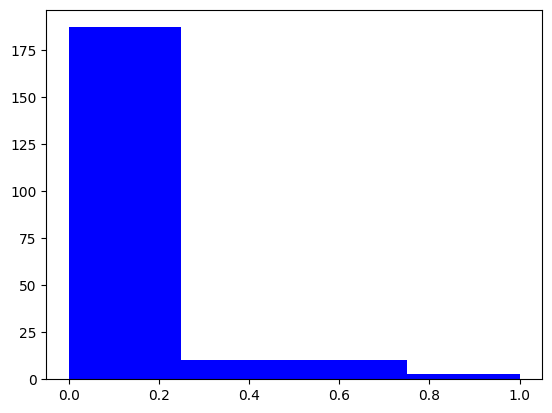

In [12]:
plt.hist(df["shares_minmax"], bins=4, color='blue')

In [13]:
standard_scaler = StandardScaler()

In [14]:
robust_scaler = RobustScaler()

In [15]:
df["view_zscore"] = standard_scaler.fit_transform(df[["views"]])

In [16]:
df[["views", "view_zscore"]].describe()

,views,view_zscore
count,2.100000e+02,2.100000e+02
mean,5.485440e+05,2.537653e-17
std,1.223751e+06,1.002389e+00
min,1.412000e+03,-4.481625e-01
25%,1.080400e+04,-4.404694e-01
50%,6.597350e+04,-3.952794e-01
75%,3.108772e+05,-1.946757e-01
max,7.038551e+06,5.316044e+00


likes

In [17]:
df["likes_zscore"] = standard_scaler.fit_transform(df[["likes"]])

In [18]:
df["likes_robust"] = robust_scaler.fit_transform(df[["likes"]])

In [19]:
df["likes_minmax"] = scaler.fit_transform(df[["likes"]])

(array([194.,  10.,   3.,   3.]),
 array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
 <BarContainer object of 4 artists>)

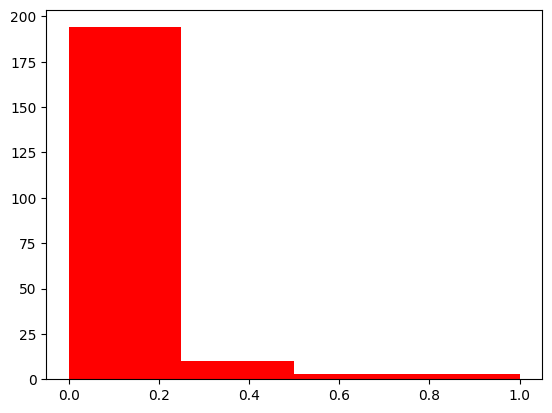

In [20]:
plt.hist(df["likes_minmax"], bins=4, color='red')

In [21]:
df[["likes", "likes_zscore", "likes_robust", "likes_minmax"]].describe()

,likes,likes_zscore,likes_robust,likes_minmax
count,210.000000,2.100000e+02,210.000000,210.000000
mean,25765.304762,8.458842e-18,1.959849,0.056527
std,66234.880530,1.002389e+00,5.509473,0.145500
min,33.000000,-3.894291e-01,-0.180586,0.000000
25%,488.750000,-3.825319e-01,-0.142676,0.001001
50%,2204.000000,-3.565735e-01,0.000000,0.004769
75%,12510.750000,-2.005926e-01,0.857324,0.027410
max,455256.000000,6.499853e+00,37.685244,1.000000


In [26]:
df["views_log"] = np.log1p(df["views"])

(array([59., 59., 56., 36.]),
 array([ 7.25347038,  9.38183104, 11.5101917 , 13.63855236, 15.76691303]),
 <BarContainer object of 4 artists>)

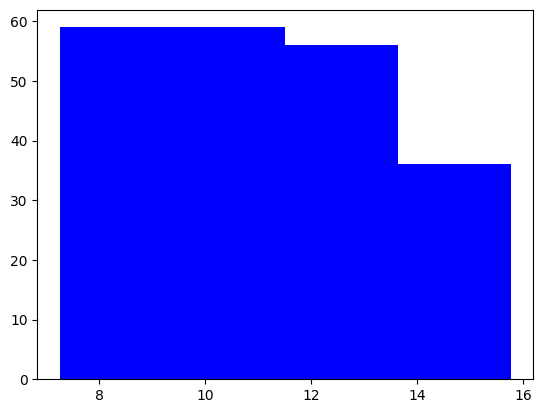

In [27]:
plt.hist(df["views_log"], bins=4, color='blue')

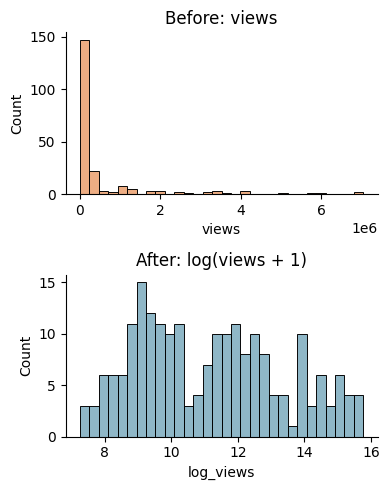

In [25]:
df["log_views"] = np.log1p(df["views"])

fig, axes = plt.subplots(2, 1, figsize=(4, 5))

sns.histplot(df["views"],
             ax=axes[0],
             color="#e8925a", bins=30)
axes[0].set_title("Before: views")
axes[0].set_xlabel("views")

sns.histplot(df["log_views"],
             ax=axes[1],
             color="#6a9fb5", bins=30)
axes[1].set_title("After: log(views + 1)")
axes[1].set_xlabel("log_views")

sns.despine()
plt.tight_layout()
plt.show()

In [30]:
bins = [0, 300, 2000, float("inf")]
labels = ['short', "medium", "long"]

df["duration_bin"] = pd.cut(df["duration_seconds"], bins=bins, labels=labels)

<Axes: xlabel='duration_bin', ylabel='count'>

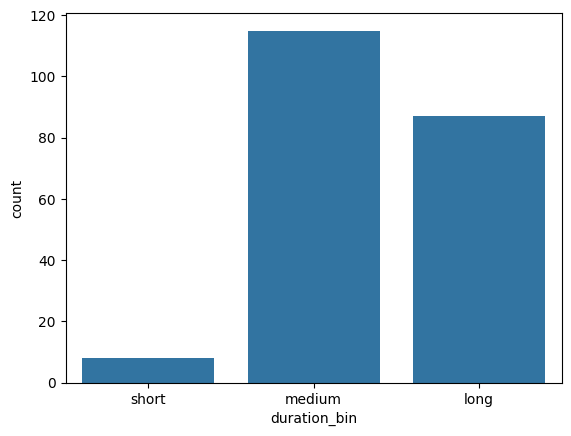

In [32]:
sns.countplot(x = "duration_bin", data=df)

choose a bin and make your own labels

In [40]:
bins = [0, 100, 3000, float("inf")]
labels = ["irrelevant", "20 seconds of fame", "meme status"]

In [41]:
df["likes_bin"] = pd.cut(df["likes"], bins=bins, labels=labels)

# OWN BAR PLOT

<Axes: title={'center': 'How relevant is YOUR YT video???'}, xlabel='likes_bin', ylabel='count'>

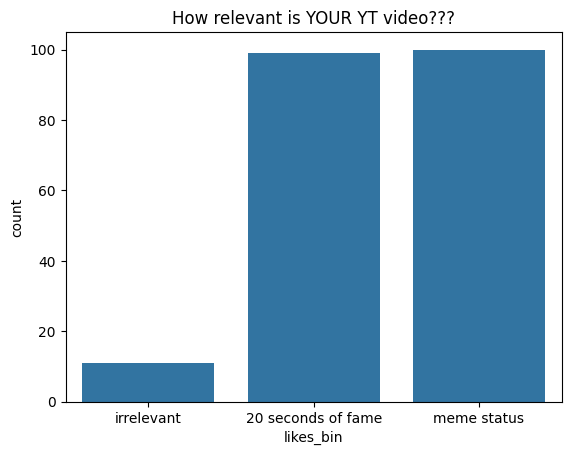

In [45]:
plt.title("How relevant is YOUR YT video???")
sns.countplot(x = "likes_bin", data=df)

In [46]:
df["channel_tier"].unique()

<StringArray>
['Mid', 'Small', 'Large']
Length: 3, dtype: str

In [71]:
encoder = OrdinalEncoder(categories=[["Small", "Mid", "Large"]])
df[["channel_tier_encoded"]] = encoder.fit_transform(df[["channel_tier"]]).astype(int)

In [76]:
df[["channel_tier","channel_tier_encoded"]]

,channel_tier,channel_tier_encoded
0,Mid,1
1,Small,0
2,Large,2
3,Mid,1
4,Small,0
...,...,...
205,Small,0
206,Small,0
207,Mid,1
208,Small,0


In [52]:
dummyVars = pd.get_dummies(df["category"], prefix="is")

In [53]:
dummyVars

,is_Comedy,is_Education,is_Gaming,is_Music,is_News,is_Vlog
0,False,False,False,True,False,False
1,False,False,True,False,False,False
2,False,False,True,False,False,False
3,False,False,True,False,False,False
4,False,False,False,True,False,False
...,...,...,...,...,...,...
205,False,True,False,False,False,False
206,False,False,False,False,True,False
207,False,False,True,False,False,False
208,True,False,False,False,False,False


In [55]:
df = pd.concat([df, dummyVars], axis=1) 

In [57]:
day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
rng = np.random.default_rng(42)
base = pd.Timestamp("2024-01-01")

df["uploaded_at"] = [
    base
    + pd.offsets.Week(weekday=day_map[d])
    + pd.Timedelta(hours=int(h))
    + pd.Timedelta(minutes=int(rng.integers(0, 60)))
    for d, h in zip(df["upload_day"], df["upload_hour"])
]

In [58]:
df["uploaded_at"].dt.dayofweek

0      6
1      5
2      0
3      3
4      0
      ..
205    4
206    5
207    6
208    3
209    4
Name: uploaded_at, Length: 210, dtype: int32

In [63]:
df["caps_count"] = df["title"].apply(
    countCaps
)
df["lower_count"] = df["title"].apply(
    lambda t: sum(1 for w in t.split() if w.islower())
)

In [64]:
df["caps_count"]

0      3
1      1
2      0
3      0
4      4
      ..
205    3
206    2
207    0
208    2
209    3
Name: caps_count, Length: 210, dtype: int64

In [62]:
def countCaps(t):
    sum = 0
    words = t.split()
    for word in words:
        if word.isupper():
            sum = sum+1
    return sum

In [65]:
df["lower_count"]

0      6
1      6
2      7
3      3
4      5
      ..
205    6
206    9
207    4
208    9
209    3
Name: lower_count, Length: 210, dtype: int64

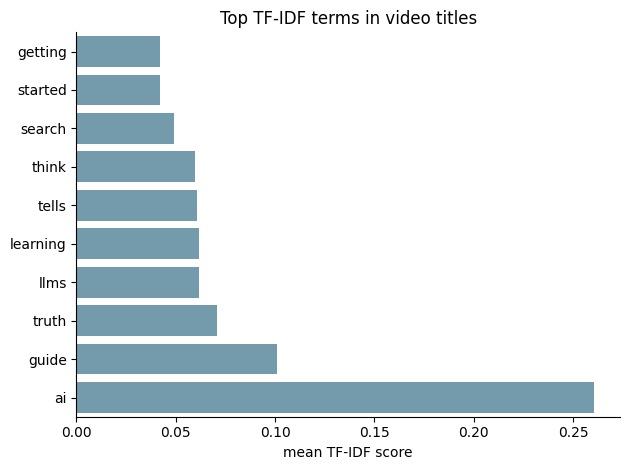

In [66]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10, stop_words="english")
tfidf_matrix = vectorizer.fit_transform(df["title"])

terms = vectorizer.get_feature_names_out()
mean_scores = tfidf_matrix.toarray().mean(axis=0)

tfidf_df = pd.DataFrame({
    "term": terms,
    "mean_tfidf": mean_scores
}).sort_values("mean_tfidf", ascending=True)

sns.barplot(data=tfidf_df,
            x="mean_tfidf",
            y="term",
            color="#6a9fb5")

plt.title("Top TF-IDF terms in video titles")
plt.xlabel("mean TF-IDF score")
plt.ylabel("")
sns.despine()
plt.tight_layout()
plt.show()

In [68]:
df["duration_minutes"] = df["duration_seconds"] / 60
df["retention_rate"] = df["watch_time_minutes"] / df["views"] * df["duration_minutes"]

In [70]:
df["duration_minutes"] 

0      12.016667
1      31.566667
2      23.550000
3      22.250000
4      52.633333
         ...    
205    28.950000
206    96.266667
207    43.616667
208    60.933333
209    13.383333
Name: duration_minutes, Length: 210, dtype: float64

In [74]:
import json
df["hashtags"] = df["hashtags"].apply(json.loads)

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
hashtag_encoded = pd.DataFrame(
    mlb.fit_transform(df["hashtags"]),
    columns=mlb.classes_,
    index=df.index
)

result = pd.concat([df[["video_id"]], hashtag_encoded], axis=1)
print(result.head(4).to_string(index=False))

video_id  ai  chatgpt  comedy  datascience  deeplearning  explained  gaming  howto  llm  machinelearning  music  news  python  review  shorts  tech  trending  tutorial  viral  vlog
vid_0000   1        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         1         1      0     0
vid_0001   0        0       0            0             0          0       0      0    0                0      0     0       0       0       0     0         0         1      0     0
vid_0002   0        0       0            0             0          1       0      0    0                0      0     0       0       0       0     0         0         0      0     0
vid_0003   0        0       0            0             0          1       1      0    0                0      0     0       0       0       0     1         1         0      0     0
